In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from lo_tools import Lfun, zfun

In [3]:
ds_bulk = xr.open_dataset('~/LO_output/extract/ae0_tgrdnt_xa0/tef2/bulk_2020.01.15_2020.03.15/mouth.nc')
print(ds_bulk)

<xarray.Dataset> Size: 48kB
Dimensions:  (time: 59, layer: 32)
Coordinates:
  * time     (time) datetime64[ns] 472B 2020-01-16T12:00:00 ... 2020-03-14T12...
  * layer    (layer) int64 256B 0 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30 31
Data variables:
    salt     (time, layer) float64 15kB ...
    q        (time, layer) float64 15kB ...
    salt2    (time, layer) float64 15kB ...
    qnet     (time) float64 472B ...
    fnet     (time) float64 472B ...
    ssh      (time) float64 472B ...
    qabs     (time) float64 472B ...
    qprism   (time) float64 472B ...


In [4]:
ds_processed = xr.open_dataset('~/LO_output/extract/ae0_tgrdnt_xa0/tef2/processed_2020.01.15_2020.03.15/mouth.nc')
print(ds_processed)

<xarray.Dataset> Size: 35MB
Dimensions:  (time: 1465, sbins: 1000)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2020-01-15 ... 2020-03-16
  * sbins    (sbins) float64 8kB 0.018 0.054 0.09 0.126 ... 35.91 35.95 35.98
Data variables:
    qnet     (time) float64 12kB ...
    fnet     (time) float64 12kB ...
    ssh      (time) float64 12kB ...
    salt     (time, sbins) float64 12MB ...
    q        (time, sbins) float64 12MB ...
    salt2    (time, sbins) float64 12MB ...


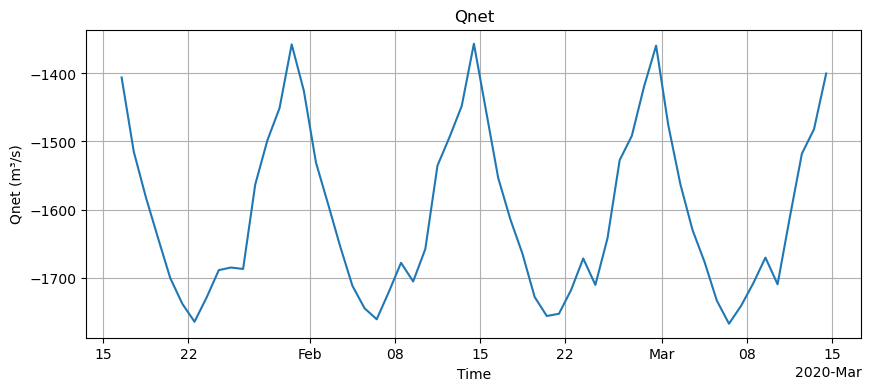

In [ ]:
ds_bulk.qnet.plot(figsize=(10, 4))
plt.title("Qnet")
plt.xlabel("Time")
plt.ylabel("Qnet (m³/s)")
plt.grid(True)
plt.show()

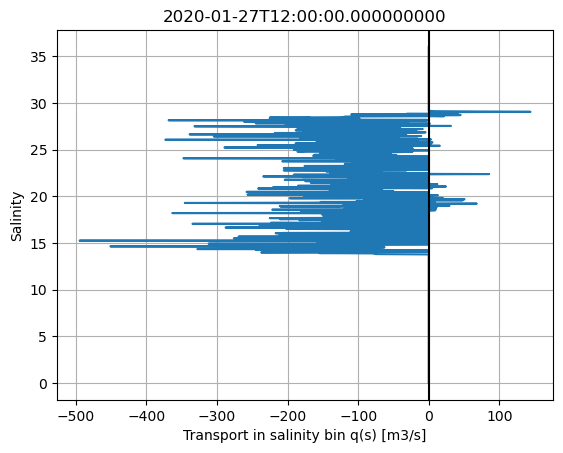

In [14]:
tt = 300  # pick a time index
q = ds_processed['q'].isel(time=tt).values
sbins = ds_processed['sbins'].values

plt.figure()
plt.plot(q, sbins)
plt.axvline(0,color='k')
plt.xlabel('Transport in salinity bin q(s) [m3/s]')
plt.ylabel('Salinity')
plt.title(str(ds_processed.time.values[tt]))
plt.grid(True)
plt.show()

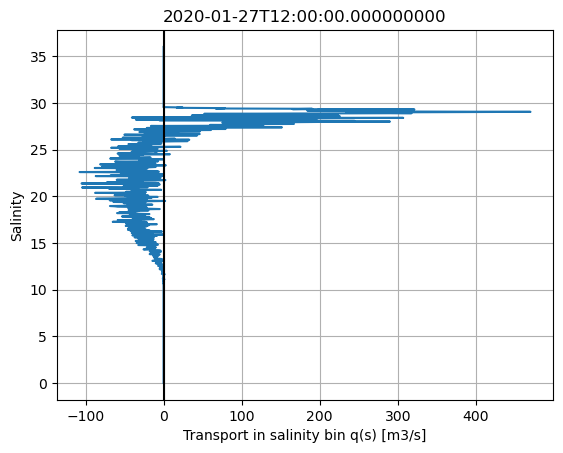

In [7]:
tt = 11  # pick a time index

# godin filter step

# convert to numpy
q_raw = ds_processed['q'].values
q_lp = zfun.lowpass(q_raw, f = 'godin')

pad = 36

q_lp= q_lp[pad:-pad+1:24, :]

time_lp = ds_processed.time.values[pad:-pad+1:24]

# pick time AFTER filtering 
q = q_lp[tt, :]

sbins = ds_processed['sbins'].values

plt.figure()
plt.plot(q, sbins)
plt.axvline(0,color='k')
plt.xlabel('Transport in salinity bin q(s) [m3/s]')
plt.ylabel('Salinity')
plt.title(str(time_lp[tt]))
plt.grid(True)
plt.show()